Saving little-cat-sitting-grass.jpg to little-cat-sitting-grass.jpg


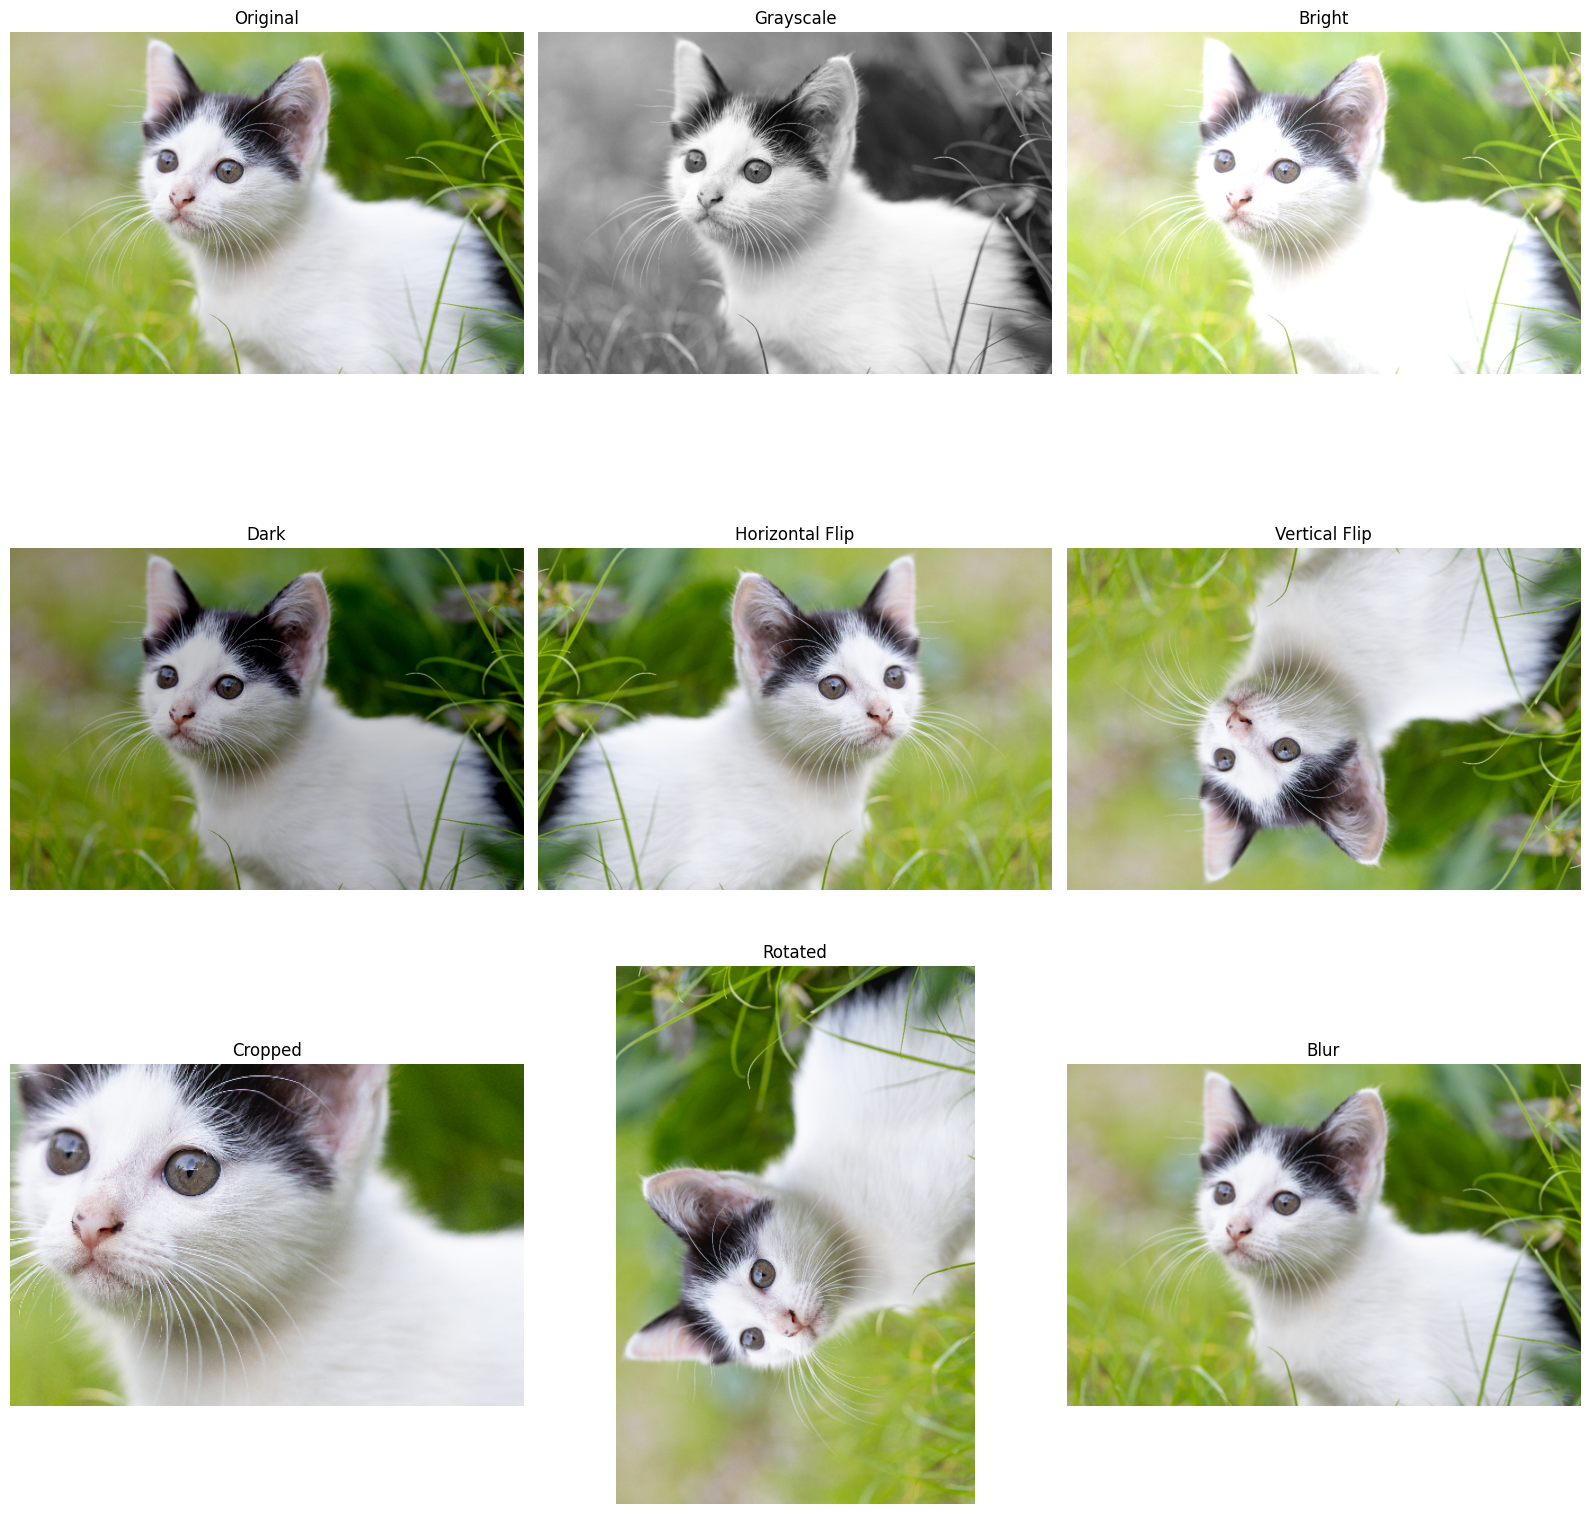

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import uniform_filter
from google.colab import files

uploaded = files.upload()

image_name = next(iter(uploaded))
image = mpimg.imread(image_name)

image = image[::6, ::6]

if image.dtype == np.uint8:
    image_float = image / 255.0
else:
    image_float = image

image_float = np.clip(image_float, 0, 1)

gray_image = np.mean(image_float[:, :, :3], axis=2)

bright_image = np.clip(image_float + 0.2, 0, 1)
dark_image = np.clip(image_float - 0.2, 0, 1)

horizontal_flip = np.fliplr(image_float)
vertical_flip = np.flipud(image_float)

height, width = image_float.shape[:2]

cropped_image = image_float[height//4:3*height//4, width//4:3*width//4]

rotated_image = np.rot90(image_float)

blur_image = uniform_filter(image_float, size=(3, 3, 1))
blur_image = np.clip(blur_image, 0, 1)

fig, axes = plt.subplots(3, 3, figsize=(16, 16))

axes[0, 0].imshow(image_float)
axes[0, 0].set_title("Original")

axes[0, 1].imshow(gray_image, cmap="gray")
axes[0, 1].set_title("Grayscale")

axes[0, 2].imshow(bright_image)
axes[0, 2].set_title("Bright")

axes[1, 0].imshow(dark_image)
axes[1, 0].set_title("Dark")

axes[1, 1].imshow(horizontal_flip)
axes[1, 1].set_title("Horizontal Flip")

axes[1, 2].imshow(vertical_flip)
axes[1, 2].set_title("Vertical Flip")

axes[2, 0].imshow(cropped_image)
axes[2, 0].set_title("Cropped")

axes[2, 1].imshow(rotated_image)
axes[2, 1].set_title("Rotated")

axes[2, 2].imshow(blur_image)
axes[2, 2].set_title("Blur")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()